   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


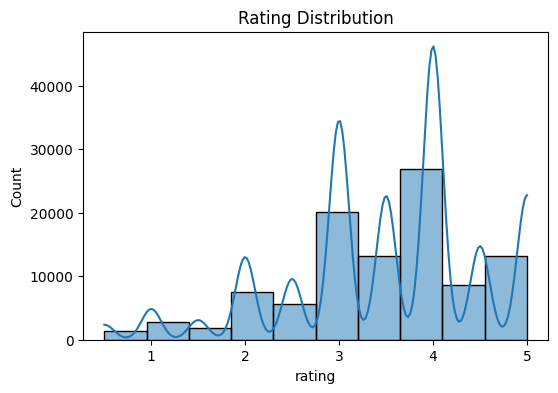

MSE: 0.9275476571796907
RMSE: 0.9630927562699715
MAE: 0.7396216779055932
R2 Score: 0.1568061583616127
Accuracy: 0.6570805236017453

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.51      0.53      7829
           1       0.71      0.75      0.73     12339

    accuracy                           0.66     20168
   macro avg       0.64      0.63      0.63     20168
weighted avg       0.65      0.66      0.65     20168



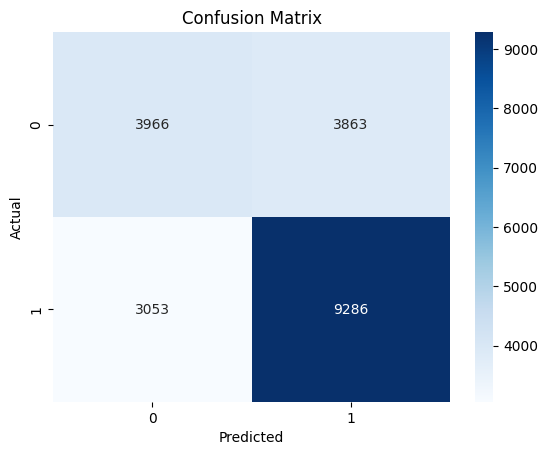

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")
print(data.head())

plt.figure(figsize=(6,4))
sns.histplot(data['rating'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.show()

# Convert genres into numeric
data['genres'] = data['genres'].astype('category').cat.codes

# Features & target
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=100)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)

X = data[['userId', 'movieId', 'genres']]
y_cls = data['rating_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)


X = data[['userId', 'movieId', 'genres']]
y_cls = data['rating_class']

print("Accuracy:", accuracy_score(y_test, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cls))

cm = confusion_matrix(y_test, y_pred_cls)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()